In [1]:
%load_ext autoreload
%autoreload 2
import xarray as xr
import pandas as pd
import numpy as np
from yllib.function import myfunc
from yllib.plot import plot_map
from cartopy import crs as ccrs
import matplotlib.pyplot as plt
import matplotlib as mpl
import einops

%config InlineBackend.figure_format='retina'

In [2]:
version = 'results_v3.1'

In [3]:
loc_Humboldt = [-124.5907, 40.97]
loc_Morro    = [-121.8581, 35.7107]

In [4]:
# dataroot = '/global/cfs/projectdirs/m4506/jderm/attributions/'
dataroot = '/global/cfs/projectdirs/m4506/jderm/results_att_humboldt/'

In [5]:
def parse_wrf_filename(filename):
    # Extract filename components
    file_part = filename.split("/")[-1]  # Get '202001_*.npy'
    date_str, hour_str = file_part.split("_")  # Split into date and hour parts
    hour = int(hour_str.split(".")[0])  # Convert hour number to integer

    # Parse base date from date string
    year = int(date_str[:4])
    month = int(date_str[4:6])
    base_date = pd.to_datetime(f"{year}-{month}-01")
   
    # Calculate timestamp by adding hours
    return base_date + pd.Timedelta(hours=hour)

time = pd.read_csv('./results_v3.1/apr3_key.csv', index_col=0).index
time = pd.Series(time.values)
time = time[:8881]
time = time.apply(parse_wrf_filename)
print(time)

0      2020-10-01 01:00:00
1      2020-10-01 02:00:00
2      2020-10-01 03:00:00
3      2020-10-01 04:00:00
4      2020-10-01 05:00:00
               ...        
8876   2021-09-30 19:00:00
8877   2021-09-30 20:00:00
8878   2021-09-30 21:00:00
8879   2021-09-30 22:00:00
8880   2021-09-30 23:00:00
Length: 8881, dtype: datetime64[ns]


In [6]:
lat = np.linspace(10, 70, 24)
lon = np.linspace(-150, -40, 44)

channel = ['u200_0','u500_0','u700_0','v200_0','v500_0','v700_0','z200_0','z500_0','z700_0','t200_0','t500_0','t700_0','sp_0','2t_0','2d_0',
           'u200_1','u500_1','u700_1','v200_1','v500_1','v700_1','z200_1','z500_1','z700_1','t200_1','t500_1','t700_1','sp_1','2t_1','2d_1']

In [7]:
attribution = []
for i, t in enumerate(time):
    arr = np.load(f'{dataroot}/attributions_{i:04}.npy').squeeze()
    print(arr.shape)
    # arr = einops.rearrange(arr, '(h ph) (w pw) -> h w (ph pw)', ph=10, pw=10)
    # arr = arr.max(axis=-1)
    arr = xr.DataArray(arr, dims=['channel', 'lat', 'lon'], coords={'channel': channel, 'lat': lat, 'lon': lon})
    attribution.append(arr)
attribution = xr.concat(attribution, dim='time')
attribution 


(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)
(30, 24, 44)

<xarray.DataArray (time: 8881, channel: 30, lat: 24, lon: 44)> Size: 1GB
array([[[[0.01531917, 0.01499658, 0.00700797, ..., 0.00329687,
          0.00585801, 0.0059091 ],
         [0.11623327, 0.04384502, 0.0273766 , ..., 0.00102717,
          0.00161187, 0.00128055],
         [0.02126745, 0.0639834 , 0.03628566, ..., 0.00437651,
          0.00574874, 0.0071601 ],
         ...,
         [0.03056897, 0.12801589, 0.01601498, ..., 0.00857036,
          0.0445308 , 0.00432908],
         [0.06326204, 0.03801018, 0.0272052 , ..., 0.01193443,
          0.01450385, 0.02729679],
         [0.01336697, 0.03469932, 0.04829562, ..., 0.01991942,
          0.00989197, 0.00625862]],

        [[0.00222167, 0.01008066, 0.00284366, ..., 0.0049444 ,
          0.00691461, 0.00624099],
         [0.02486998, 0.00784656, 0.008765  , ..., 0.00255161,
          0.00338551, 0.00428979],
         [0.02352529, 0.01012986, 0.01093631, ..., 0.00094287,
          0.00051484, 0.00216719],
...
         [0.00281414, 0.00431425, 0.00513511, ..., 0.01447928,
          0.00498397, 0.00421875],
         [0.00340361, 0.00273707, 0.00303755, ..., 0.00971225,
          0.0070695 , 0.00442857],
         [0.00856488, 0.00500612, 0.00442753, ..., 0.00923637,
          0.01620403, 0.00789845]],

        [[0.00407282, 0.00790318, 0.00394121, ..., 0.006672  ,
          0.0050378 , 0.00623275],
         [0.01225307, 0.00886637, 0.00900172, ..., 0.00366613,
          0.00296244, 0.00265948],
         [0.00630397, 0.00678163, 0.01448437, ..., 0.00344692,
          0.01002952, 0.00453288],
         ...,
         [0.00140648, 0.00392457, 0.00179873, ..., 0.00841908,
          0.00330618, 0.00222415],
         [0.00231353, 0.00218292, 0.00204128, ..., 0.0016888 ,
          0.00684031, 0.00371622],
         [0.01378147, 0.00180768, 0.00309887, ..., 0.00420365,
          0.00349507, 0.00708477]]]], dtype=float32)
Coordinates:
  * channel  (channel) <U6 720B 'u200_0' 'u500_0' 'u700_0' ... '2t_1' '2d_1'
  * lat      (lat) float64 192B 10.0 12.61 15.22 17.83 ... 64.78 67.39 70.0
  * lon      (lon) float64 352B -150.0 -147.4 -144.9 ... -45.12 -42.56 -40.0
Dimensions without coordinates: time

In [8]:
attribution.coords['time'] = time
attribution.name = 'attribution'
attribution.to_netcdf('results_v3.1/attribution_var.humboldt.nc')

In [9]:
attribution = xr.open_dataarray('results_v3.1/attribution_var.humboldt.nc')

## Plot figures

In [10]:
def plot_on_map(data, u=None, v=None, **kwargs):
    mpl.rcParams['font.size'] = 15
    mpl.rcParams['font.family'] = 'Helvetica'  
    
    # create a figure
    if (fig:=kwargs.get('fig')) is None:  
        fig = plt.figure(figsize=(8, 5))
    if (ax:=kwargs.get('ax')) is None:  ax = plt.axes()
    ax.set_axis_on()
    
    # set map - extent, grid, coastline ...
    plot_map.set_map(
        ax,
        extent=kwargs.get('extent',[-125,-70,24,50]),
        # extent=[0,360,15,90],
        gridlines_kw=dict(
            xticks=[-150,-140,-130,-120,-110,-100,-90,-80,-70,-60,-50,-40],
            yticks=[10,20,30,40,50,60,70],
            linestyle=":", alpha=0.3,
        ),
        gridlabels_kw=dict(
            xticks=[-140,-120,-100,-80,-60,-40] if kwargs.get('drawxticks', False) else [],
            yticks=[10,20,30,40,50,60,70] if kwargs.get('drawyticks', False) else [],
        ),
        boundary_kw=dict(
            draw_state=True,
            coastline_kw=dict(linewidth=0.9, alpha=0.7, color='k'),
            draw_borders=True,
            border_kw=dict(linewidth=0.9, alpha=0.7, color='k'),
        ),
    )
    
    # lat and lon for contour plot
    if ((lon:=kwargs.get('lon')) is None): lon = data['lon']
    if ((lat:=kwargs.get('lat')) is None): lat = data['lat']
        
    # draw contourf
    cmap = kwargs.get('cmap', "WhiteBlueGreenYellowRed")
    clev = kwargs.get('clev', np.arange(0, 40, 1))
    # cs, clev = plot_map.add_contourf(
    cs, clev = plot_map.add_pcolormesh(
        ax, lon, lat, data,
        # cmap=cm_wind['cmap'],clev=clev,
        cmap=cmap,clev=clev,
    )
    # plot_map.add_contour(ax, lon, lat, data, clev=[0, 0.25,0.5,0.75,1], colors='k', zorder=10)        
    # plot_map.add_contour(ax, lon, lat, data, clev=[0, 0.1,0.2,0.3,0.4,0.5,0.75,1], colors='k', zorder=10)        
    
    # cs = ax.contourf(lon, lat, data, cmap=cm_wind['cmap'], norm=cm_wind['norm'], clev=clev)
    if (u is not None) & (v is not None):
        d = 20
        _lat = lat[::d,::d]
        _lon = lon[::d,::d]
        # uu, vv = rotate_wind(u[::d,::d], v[::d,::d], _lon)
        uu, vv = u[::d,::d], v[::d,::d]
        vec = plot_map.add_vector(ax,
            _lon, _lat, uu, vv,
            vector_kwargs=dict(
                scale_units="inches", scale=kwargs.get('vector_scale',30),
            )
        )
        rect = mpl.patches.Rectangle(
            (0., 0),  # (x, y)
            0.25,  # width
            0.1,  # height
            facecolor='white',
            edgecolor='gray',
            transform=ax.transAxes,
        )
        ax.add_patch(rect)
        ax.quiverkey(vec, 0.10, 0.05, 5, "5",labelpos='E', coordinates='axes')
    
    if (overlay:=kwargs.get('overlay')) is not None:
        plot_map.add_hatches(ax, lon, lat, overlay, clev=[0, 0.05], zorder=10)

        
    # add text - title, ananote
    if (title:=kwargs.get('title')) is not None: 
        default_title_kwargs = dict(loc='left')
        default_title_kwargs.update(kwargs.get('title_kwargs', {}))
        ax.set_title(title, **default_title_kwargs)

    if kwargs.get('draw_colorbar'):
        plot_map.add_colorbar(cs, ax, clev[1:-1])
        
    return cs, clev

Channels used: ['u200_0', 'u500_0', 'u700_0', 'v200_0', 'v500_0', 'v700_0', 'z200_0', 'z500_0', 'z700_0', 't200_0', 't500_0', 't700_0', 'sp_0', '2t_0', '2d_0']
Event 0: (a) AR Humboldt has 13 timesteps
Event 0: Major ticks at positions [0, 4, 8, 12]
Event 1: (c) Downslope Humboldt has 13 timesteps
Event 1: Major ticks at positions [0, 4, 8, 12]
Event 2: (e) LLJ Humboldt has 13 timesteps
Event 2: Major ticks at positions [0, 4, 8, 12]
Normalization: ON


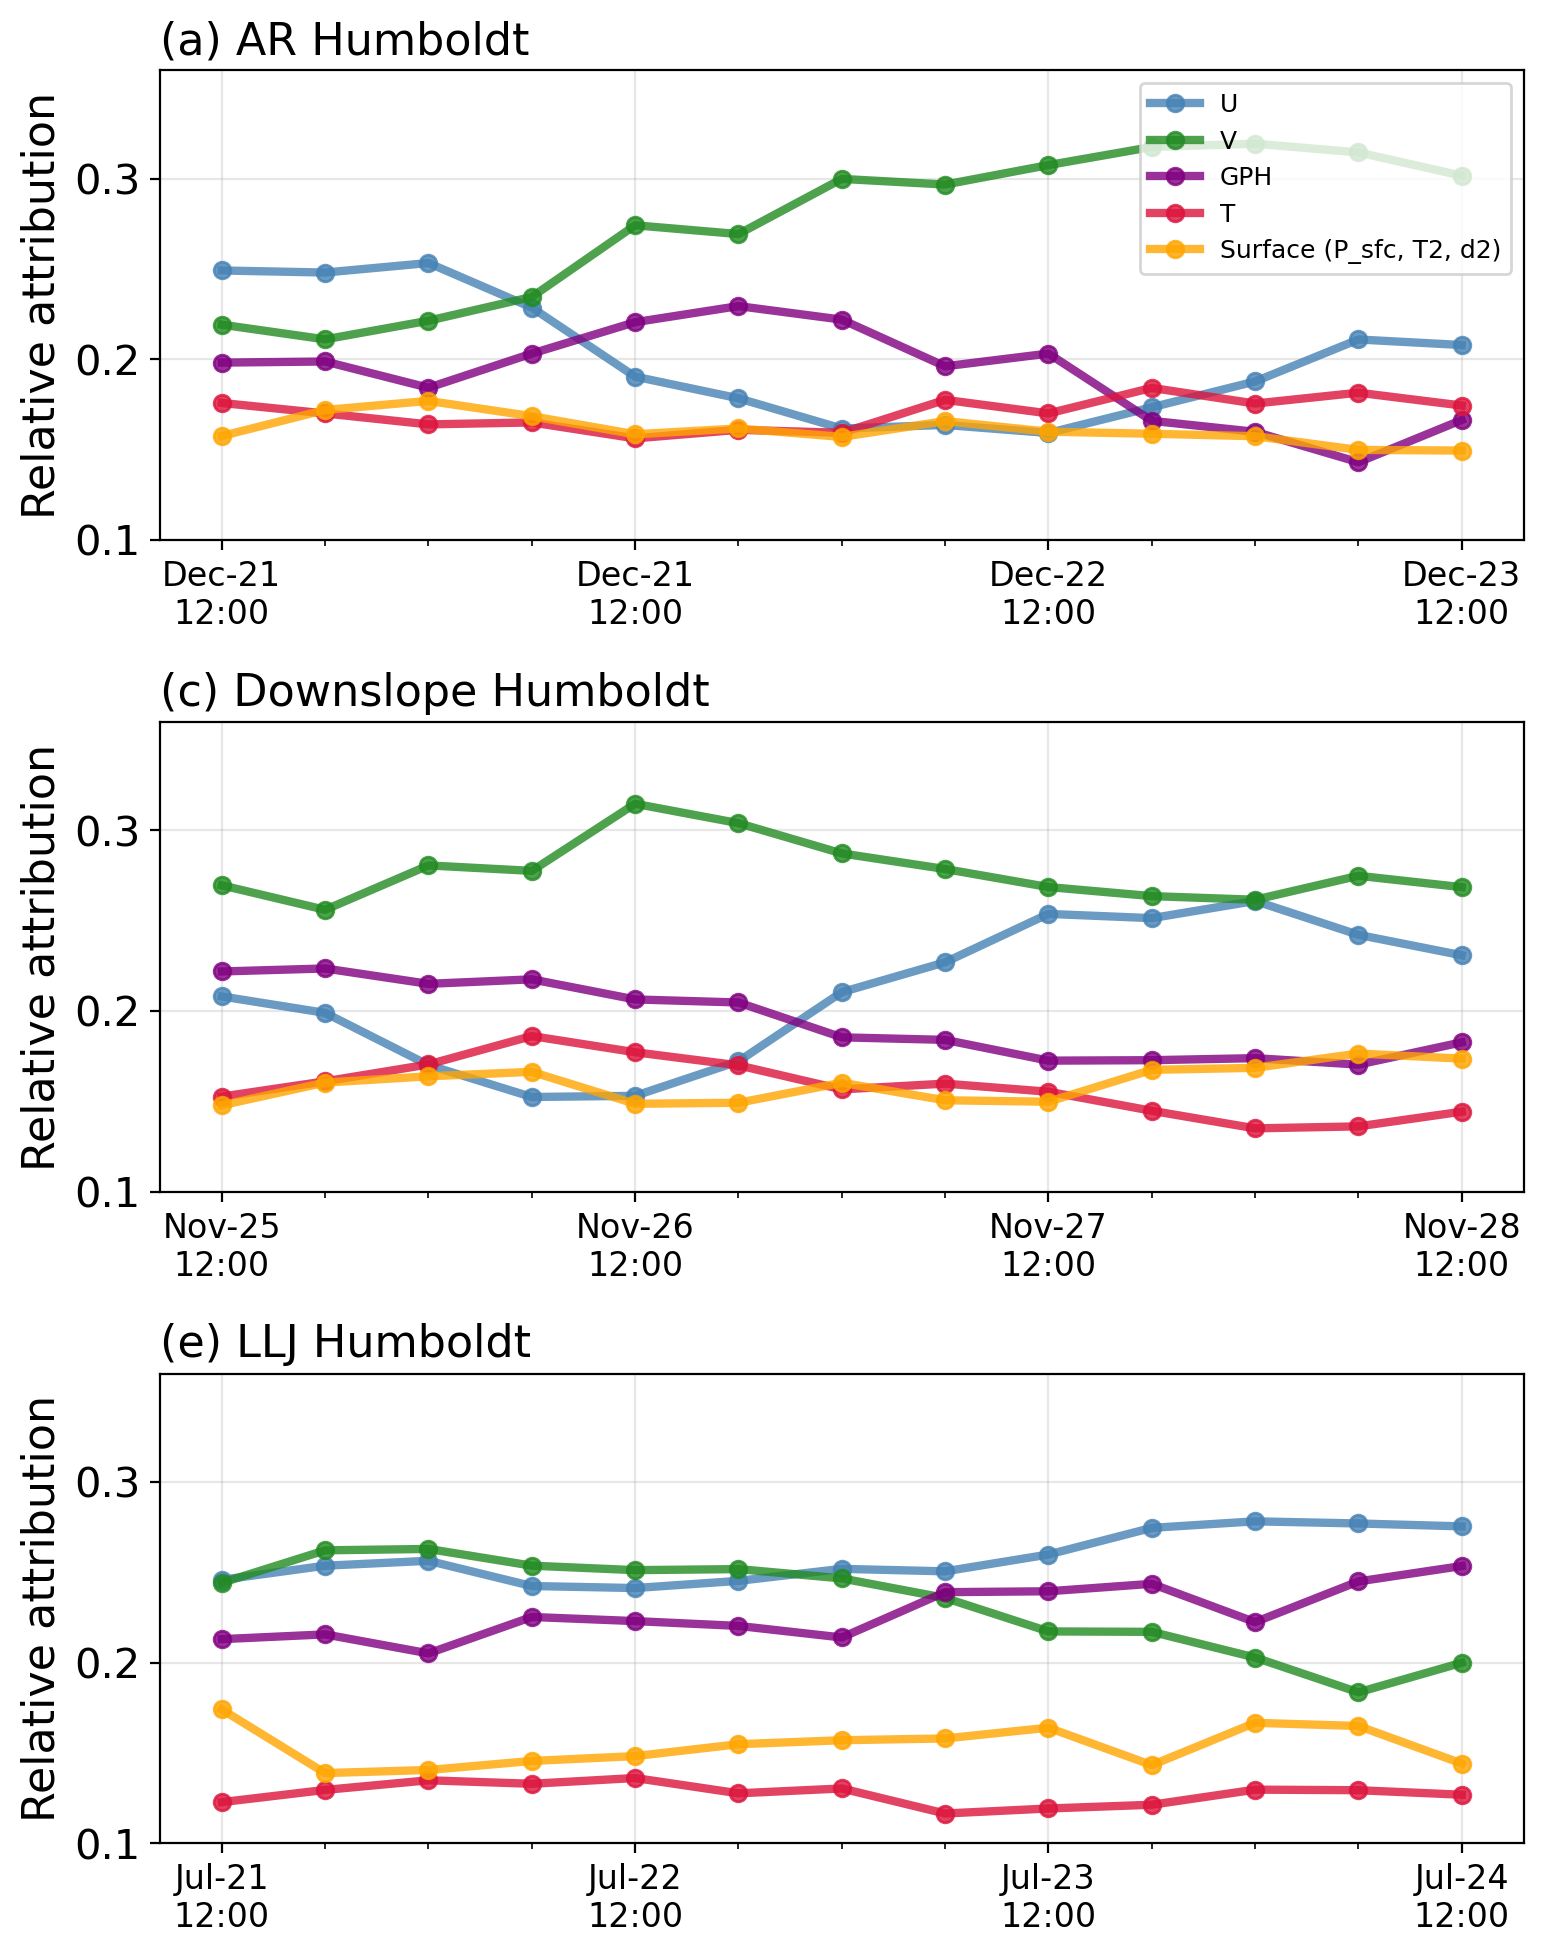

In [23]:
events = [
    ('(a) AR Humboldt',        '2020-12-21 00:00:00', '2020-12-24 00:00:00'),
    ('(c) Downslope Humboldt', '2020-11-25 00:00:00', '2020-11-28 00:00:00'),
    ('(e) LLJ Humboldt',       '2021-07-21 00:00:00', '2021-07-24 00:00:00'),
]

# Add normalization option
NORMALIZE_BARS = True  # Set to True to normalize each timestep to sum=1

# Use only the first 15 channels (current hour _0)
channels_t0 = channel[:15]
print("Channels used:", channels_t0)

# Define variable groups for the first 15 channels only
var_groups = {
    'u_wind': ['u200_0', 'u500_0', 'u700_0'],
    'v_wind': ['v200_0', 'v500_0', 'v700_0'],
    'geopotential': ['z200_0', 'z500_0', 'z700_0'],
    'temperature': ['t200_0', 't500_0', 't700_0'],
    'surface': ['sp_0', '2t_0', '2d_0']
}

# Define single colors for each variable group
group_colors = {
    'u_wind': 'steelblue',
    'v_wind': 'forestgreen',
    'geopotential': 'purple',
    'temperature': 'crimson',
    'surface': 'orange'
}

group_names = {
    'u_wind': 'U',
    'v_wind': 'V',
    'geopotential': 'GPH',
    'temperature': 'T',
    'surface': 'Surface (P_sfc, T2, d2)'
}

fig, axs = plt.subplots(3, 1, figsize=(8, 10), dpi=100)
plt.subplots_adjust(hspace=0.4)

for i, (ax, event) in enumerate(zip(axs, events)):
    # Get event data and calculate regional mean
    att_event = attribution.sel(time=slice(event[1], event[2]))
    att_event_mean = att_event.sel(lon=slice(-150, -100), lat=slice(10, 70)).mean(['lat', 'lon'])
    
    # Use only first 15 channels (current hour)
    att_event_mean = att_event_mean.isel(channel=slice(0, 15))
    
    # Subsample every 6 hours (assuming hourly data)
    att_event_mean = att_event_mean.isel(time=slice(None, None, 6))
    
    # Convert time to datetime for proper formatting
    times = pd.to_datetime(att_event_mean.time.values)
    print(f"Event {i}: {event[0]} has {len(times)} timesteps")
    
    # Create time index for x-axis
    time_steps = range(len(att_event_mean.time))
    
    # Calculate group means
    group_means = {}
    all_group_data = []
    
    for group_name, var_list in var_groups.items():
        group_data = []
        for var_name in var_list:
            if var_name in channels_t0:
                ch_idx = channels_t0.index(var_name)
                channel_data = att_event_mean.isel(channel=ch_idx).values
                group_data.append(channel_data)
        
        if group_data:
            group_mean = np.mean(group_data, axis=0)
            group_means[group_name] = group_mean
            all_group_data.append(group_mean)
    
    # Calculate total for normalization
    total_data = np.sum(all_group_data, axis=0)
    
    # Plot group means as lines
    for group_name, group_mean in group_means.items():
        # Apply normalization if requested
        if NORMALIZE_BARS:
            # Avoid division by zero
            normalized_data = np.where(total_data != 0, group_mean / total_data, 0)
            plot_data = normalized_data
        else:
            plot_data = group_mean
        
        # Plot line with markers
        ax.plot(time_steps, plot_data, 
                color=group_colors[group_name], alpha=0.8, linewidth=3, 
                marker='o', markersize=6, label=group_names[group_name])
    
    # Formatting
    ax.set_title(f'{event[0]}', fontsize=16, loc='left')
    
    # Set appropriate y-label based on normalization
    if NORMALIZE_BARS:
        ax.set_ylabel('Relative attribution', fontsize=16)
        ax.set_ylim(0.1, 0.36)  # Reasonable upper limit for group means
    else:
        ax.set_ylabel('Regional mean attribution', fontsize=11)
    
    # Add legend (only on first subplot)
    if i == 0:
        ax.legend(loc='upper right', fontsize=9)
    
    ax.grid(True, alpha=0.3)
    
    # Improved x-axis formatting - ensure consistent spacing
    n_days = len(times) // 4  # Approximate number of days (4 timesteps per day at 6-hour intervals)
    
    if len(times) <= 4:
        # For very short events, show all timesteps
        major_ticks = list(range(len(times)))
        major_labels = [f"{t.strftime('%b-%d')}\n{t.strftime('%H:%M')}" for t in times]
    else:
        # For longer events, space ticks evenly
        if n_days >= 2:
            # Show daily ticks
            major_ticks = list(range(0, len(times), 4))  # Every 24 hours (4 * 6-hour intervals)
            major_labels = [f"{times[j].strftime('%b-%d')}\n12:00" for j in major_ticks]
        else:
            # Show every 12 hours
            major_ticks = list(range(0, len(times), 2))  # Every 12 hours (2 * 6-hour intervals)
            major_labels = [f"{times[j].strftime('%b-%d')}\n{times[j].strftime('%H:%M')}" for j in major_ticks]
    
    # Ensure we don't go beyond the data length
    major_ticks = [t for t in major_ticks if t < len(times)]
    major_labels = major_labels[:len(major_ticks)]
    
    ax.set_xticks(list(range(len(times))), minor=True)
    ax.set_xticks(major_ticks)
    ax.set_xticklabels(major_labels, fontsize=12, ha='center')
    
    print(f"Event {i}: Major ticks at positions {major_ticks}")

print(f"Normalization: {'ON' if NORMALIZE_BARS else 'OFF'}")
plt.tight_layout()
plt.show()